# 17.1 - Analisis cualitativo de ResNet101 + TTA

Este notebook reconstruye el modelo del experimento 17 y genera ejemplos cualitativos sobre el mismo conjunto de validacion.


In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from IPython.display import FileLink, display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)
BATCH_SIZE = 24
TTA_BATCH_SIZE = 48
EPOCHS_STAGE2 = 18
EPOCHS_STAGE3 = 12
LR_STAGE2 = 1e-5
LR_STAGE3 = 3e-6
WEIGHT_DECAY_FINE = 1e-6
LABEL_SMOOTHING = 0.03
STAGE2_TRAINABLE_LAST = 80
STAGE3_TRAINABLE_LAST = 160

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print('No se pudo activar memory_growth:', exc)

if gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')
WORKDIR.mkdir(parents=True, exist_ok=True)
print('GPUs:', gpus)
print('Politica de precision:', tf.keras.mixed_precision.global_policy())

2026-06-22 17:58:21.639674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782151101.847381      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782151101.908446      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782151102.422051      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782151102.422090      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782151102.422093      58 computation_placer.cc:177] computation placer alr

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Politica de precision: <DTypePolicy "mixed_float16">


## Datos y split de validacion

In [2]:
array_dirs = sorted({p.parent for p in KAGGLE_INPUT_DIR.rglob('X_all.npy')})
if not array_dirs:
    raise FileNotFoundError('No se encontro X_all.npy. Anade el dataset xview_arrays como Input.')

ARRAYS_DIR = array_dirs[0]
X_all = np.load(ARRAYS_DIR / 'X_all.npy')
y_all_idx = np.load(ARRAYS_DIR / 'y_all_idx.npy')
filenames = np.load(ARRAYS_DIR / 'filenames.npy').astype(str)
category_names = np.load(ARRAYS_DIR / 'category_names.npy').astype(str).tolist()
num_classes = len(category_names)

indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]
y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes).astype(np.float32)

print('ARRAYS_DIR:', ARRAYS_DIR)
print('X_train:', X_train.shape, X_train.dtype)
print('X_valid:', X_valid.shape, X_valid.dtype)
print('Clases:', category_names)

ARRAYS_DIR: /kaggle/input/datasets/eduardocama/xview-array/xview_arrays
X_train: (15934, 224, 224, 3) uint8
X_valid: (2812, 224, 224, 3) uint8
Clases: ['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']


## Reconstruccion exacta del modelo 17

In [3]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.04, fill_mode='reflect', seed=SEED + 1),
    tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode='reflect', seed=SEED + 2),
    tf.keras.layers.RandomZoom(0.05, fill_mode='reflect', seed=SEED + 3),
], name='augmentation_suave')

inputs = tf.keras.Input(shape=IMAGE_SHAPE, name='image')
x = data_aug(inputs)
x = tf.keras.layers.Lambda(
    tf.keras.applications.resnet.preprocess_input,
    name='resnet101_preprocess',
)(x)

# weights=None evita depender de Internet; el H5 restaura todos los pesos.
base = tf.keras.applications.ResNet101(
    include_top=False,
    weights=None,
    input_tensor=x,
)
base.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(base.output)
x = tf.keras.layers.BatchNormalization(name='head_bn_1')(x)
x = tf.keras.layers.Dropout(0.35, name='head_dropout_1')(x)
x = tf.keras.layers.Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name='head_dense',
)(x)
x = tf.keras.layers.BatchNormalization(name='head_bn_2')(x)
x = tf.keras.layers.Dropout(0.35, name='head_dropout_2')(x)
outputs = tf.keras.layers.Dense(
    num_classes,
    activation='softmax',
    dtype='float32',
    name='predictions',
)(x)
model = tf.keras.Model(inputs, outputs, name='resnet101_transfer_tta')

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

def make_optimizer(learning_rate, weight_decay):
    try:
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay,
        )
    except Exception:
        return tf.keras.optimizers.Adam(learning_rate=learning_rate)

def compile_model(learning_rate):
    model.compile(
        optimizer=make_optimizer(learning_rate, WEIGHT_DECAY_FINE),
        loss=loss_fn,
        metrics=['accuracy'],
    )

def set_backbone_trainable(trainable_last_n):
    base.trainable = True
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-trainable_last_n:]:
        layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    print('Capas entrenables backbone:', sum(int(layer.trainable) for layer in base.layers))

def make_callbacks(path, patience):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            str(path), monitor='val_accuracy', mode='max',
            save_best_only=True, save_weights_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', mode='max', patience=patience,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', mode='min', factor=0.3, patience=3,
            min_lr=1e-7, verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

print('Parametros:', model.count_params())

I0000 00:00:1782151152.229376      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782151152.235516      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Parametros: 43724173


## Carga de pesos o recuperacion de las etapas finales

In [4]:
def find_weight(filename):
    candidates = list(KAGGLE_INPUT_DIR.rglob(filename)) + list(WORKDIR.rglob(filename))
    return candidates[0] if candidates else None

stage1_input = find_weight('17_resnet101_stage1.weights.h5')
stage2_input = find_weight('17_resnet101_stage2.weights.h5')
stage3_input = find_weight('17_resnet101_stage3.weights.h5')
stage2_output = WORKDIR / '17_resnet101_stage2_recovered.weights.h5'
stage3_output = WORKDIR / '17_resnet101_stage3_recovered.weights.h5'

print('stage1:', stage1_input)
print('stage2:', stage2_input)
print('stage3:', stage3_input)

candidate_models = []

if stage3_input is not None:
    model.load_weights(stage3_input)
    selected_weights = stage3_input
    print('Se cargan directamente los pesos originales de stage3.')
else:
    if stage2_input is None:
        if stage1_input is None:
            raise FileNotFoundError(
                'No se encontraron pesos stage1, stage2 ni stage3 en los Inputs de Kaggle.'
            )

        model.load_weights(stage1_input)
        compile_model(LR_STAGE2)
        _, stage1_acc = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
        candidate_models.append(('stage1', float(stage1_acc), stage1_input))

        set_backbone_trainable(STAGE2_TRAINABLE_LAST)
        compile_model(LR_STAGE2)
        history_stage2 = model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            batch_size=BATCH_SIZE,
            epochs=EPOCHS_STAGE2,
            callbacks=make_callbacks(stage2_output, patience=6),
            verbose=1,
        )
        stage2_input = stage2_output
        stage2_acc = float(np.max(history_stage2.history['val_accuracy']))
        candidate_models.append(('stage2', stage2_acc, stage2_input))
    else:
        model.load_weights(stage2_input)
        set_backbone_trainable(STAGE2_TRAINABLE_LAST)
        compile_model(LR_STAGE2)
        _, stage2_acc = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
        candidate_models.append(('stage2', float(stage2_acc), stage2_input))

    model.load_weights(stage2_input)
    set_backbone_trainable(STAGE3_TRAINABLE_LAST)
    compile_model(LR_STAGE3)
    history_stage3 = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS_STAGE3,
        callbacks=make_callbacks(stage3_output, patience=5),
        verbose=1,
    )
    stage3_acc = float(np.max(history_stage3.history['val_accuracy']))
    candidate_models.append(('stage3', stage3_acc, stage3_output))

    best_stage, best_val_acc, selected_weights = max(candidate_models, key=lambda item: item[1])
    model.load_weights(selected_weights)
    print('Mejor etapa recuperada:', best_stage, best_val_acc)

print('Pesos seleccionados:', selected_weights)

stage1: /kaggle/input/models/eduardocama/17-resnet101-stage1-weights/keras/default/1/17_resnet101_stage1.weights.h5
stage2: None
stage3: None


I0000 00:00:1782151185.475681     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.7336 - loss: 1.0548
Capas entrenables backbone: 56
Epoch 1/18
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7742 - loss: 0.9288
Epoch 1: val_accuracy improved from None to 0.74467, saving model to /kaggle/working/17_resnet101_stage2_recovered.weights.h5

Epoch 1: finished saving model to /kaggle/working/17_resnet101_stage2_recovered.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 140s 172ms/step - accuracy: 0.7793 - loss: 0.9148 - val_accuracy: 0.7447 - val_loss: 1.0063 - learning_rate: 1.0000e-05
Epoch 2/18
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8044 - loss: 0.8650
Epoch 2: val_accuracy improved from 0.74467 to 0.75213, saving model to /kaggle/working/17_resnet101_stage2_recovered.weights.h5

Epoch 2: finished saving model to /kaggle/working/17_resnet101_stage2_recovered.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 109s 164ms/step - accuracy: 0.8059 - loss: 0.8594 - val_accuracy: 0.7521 - val_loss: 0.9926 - learn

## Prediccion con TTA sobre validacion

In [5]:
def predict_with_tta_array(model, images, batch_size=48):
    variants = [
        ('identity', images),
        ('hflip', np.flip(images, axis=2)),
        ('vflip', np.flip(images, axis=1)),
        ('rot90', np.rot90(images, k=1, axes=(1, 2))),
        ('rot180', np.rot90(images, k=2, axes=(1, 2))),
        ('rot270', np.rot90(images, k=3, axes=(1, 2))),
    ]
    probs_sum = None
    for name, variant in variants:
        variant = np.ascontiguousarray(variant)
        variant_probs = model.predict(variant, batch_size=batch_size, verbose=0)
        probs_sum = variant_probs if probs_sum is None else probs_sum + variant_probs
        print('TTA procesada:', name)
    return probs_sum / len(variants)

plain_probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
plain_pred_idx = np.argmax(plain_probs, axis=1)
plain_accuracy = accuracy_score(y_valid_idx, plain_pred_idx)

tta_probs = predict_with_tta_array(model, X_valid, batch_size=TTA_BATCH_SIZE)
tta_pred_idx = np.argmax(tta_probs, axis=1)
tta_accuracy = accuracy_score(y_valid_idx, tta_pred_idx)

# El experimento 17 defendido en la memoria usa TTA.
probs = tta_probs
y_true_idx = y_valid_idx
y_pred_idx = tta_pred_idx
confidences = np.max(probs, axis=1)

print('Accuracy sin TTA:', plain_accuracy)
print('Accuracy con TTA:', tta_accuracy)
print(classification_report(
    y_true_idx, y_pred_idx,
    labels=np.arange(num_classes),
    target_names=category_names,
    digits=4,
))

118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step
TTA procesada: identity
TTA procesada: hflip
TTA procesada: vflip
TTA procesada: rot90
TTA procesada: rot180
TTA procesada: rot270
Accuracy sin TTA: 0.7891180654338549
Accuracy con TTA: 0.7976529160739687
                    precision    recall  f1-score   support

       Cargo plane     0.9894    0.9789    0.9841        95
         Small car     0.7468    0.9218    0.8251       499
               Bus     0.6507    0.6679    0.6592       265
             Truck     0.5742    0.4428    0.5000       332
         Motorboat     0.8500    0.8500    0.8500       160
    Fishing vessel     0.8286    0.8208    0.8246       106
        Dump truck     0.7722    0.6595    0.7114       185
         Excavator     0.9174    0.8475    0.8811       118
          Building     0.8930    0.9443    0.9179       539
           Helipad     1.0000    0.8824    0.9375        17
      Storage tank     0.9784    0.8227    0.8938       220
Shipping container     0.7672 

## Seleccion reproducible de aciertos y fallos

In [6]:
correct_mask = y_true_idx == y_pred_idx
wrong_mask = ~correct_mask

preferred_correct_classes = [
    'Cargo plane', 'Small car', 'Building',
    'Helipad', 'Excavator', 'Pylon',
]

selected_correct = []
for class_name in preferred_correct_classes:
    if class_name not in category_names:
        continue
    class_idx = category_names.index(class_name)
    candidates = np.where(correct_mask & (y_true_idx == class_idx))[0]
    if len(candidates):
        selected_correct.append(int(candidates[np.argmax(confidences[candidates])]))

if len(selected_correct) < 6:
    remaining = np.where(correct_mask)[0]
    remaining = remaining[np.argsort(confidences[remaining])[::-1]]
    for idx in remaining:
        if int(idx) not in selected_correct:
            selected_correct.append(int(idx))
        if len(selected_correct) == 6:
            break

wrong_indices = np.where(wrong_mask)[0]
pair_counts = Counter((int(y_true_idx[i]), int(y_pred_idx[i])) for i in wrong_indices)
selected_errors = []
selected_error_counts = {}
for pair, count in pair_counts.most_common(8):
    true_idx, pred_idx = pair
    candidates = np.where(
        wrong_mask & (y_true_idx == true_idx) & (y_pred_idx == pred_idx)
    )[0]
    chosen = int(candidates[np.argmax(confidences[candidates])])
    selected_errors.append(chosen)
    selected_error_counts[chosen] = count

print('Aciertos seleccionados:', selected_correct)
print('Principales pares de error:')
for idx in selected_errors:
    true_name = category_names[int(y_true_idx[idx])]
    pred_name = category_names[int(y_pred_idx[idx])]
    print(f'- {true_name} -> {pred_name}: {selected_error_counts[idx]} casos; p={confidences[idx]:.3f}')

Aciertos seleccionados: [2657, 1325, 243, 58, 2600, 839]
Principales pares de error:
- Truck -> Small car: 84 casos; p=0.979
- Dump truck -> Truck: 44 casos; p=0.861
- Truck -> Bus: 43 casos; p=0.997
- Bus -> Small car: 32 casos; p=0.889
- Truck -> Dump truck: 27 casos; p=0.959
- Bus -> Truck: 26 casos; p=0.826
- Small car -> Bus: 19 casos; p=0.977
- Bus -> Shipping container: 18 casos; p=0.953


## Figuras para la memoria

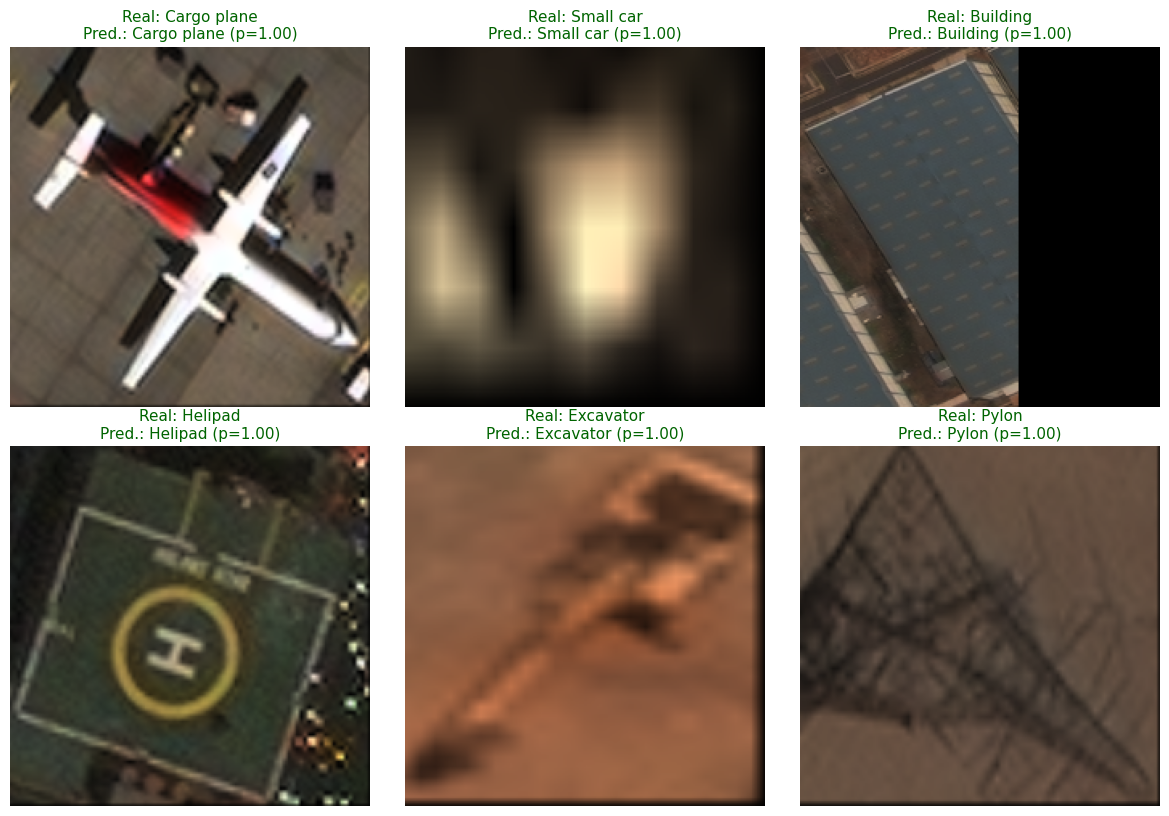

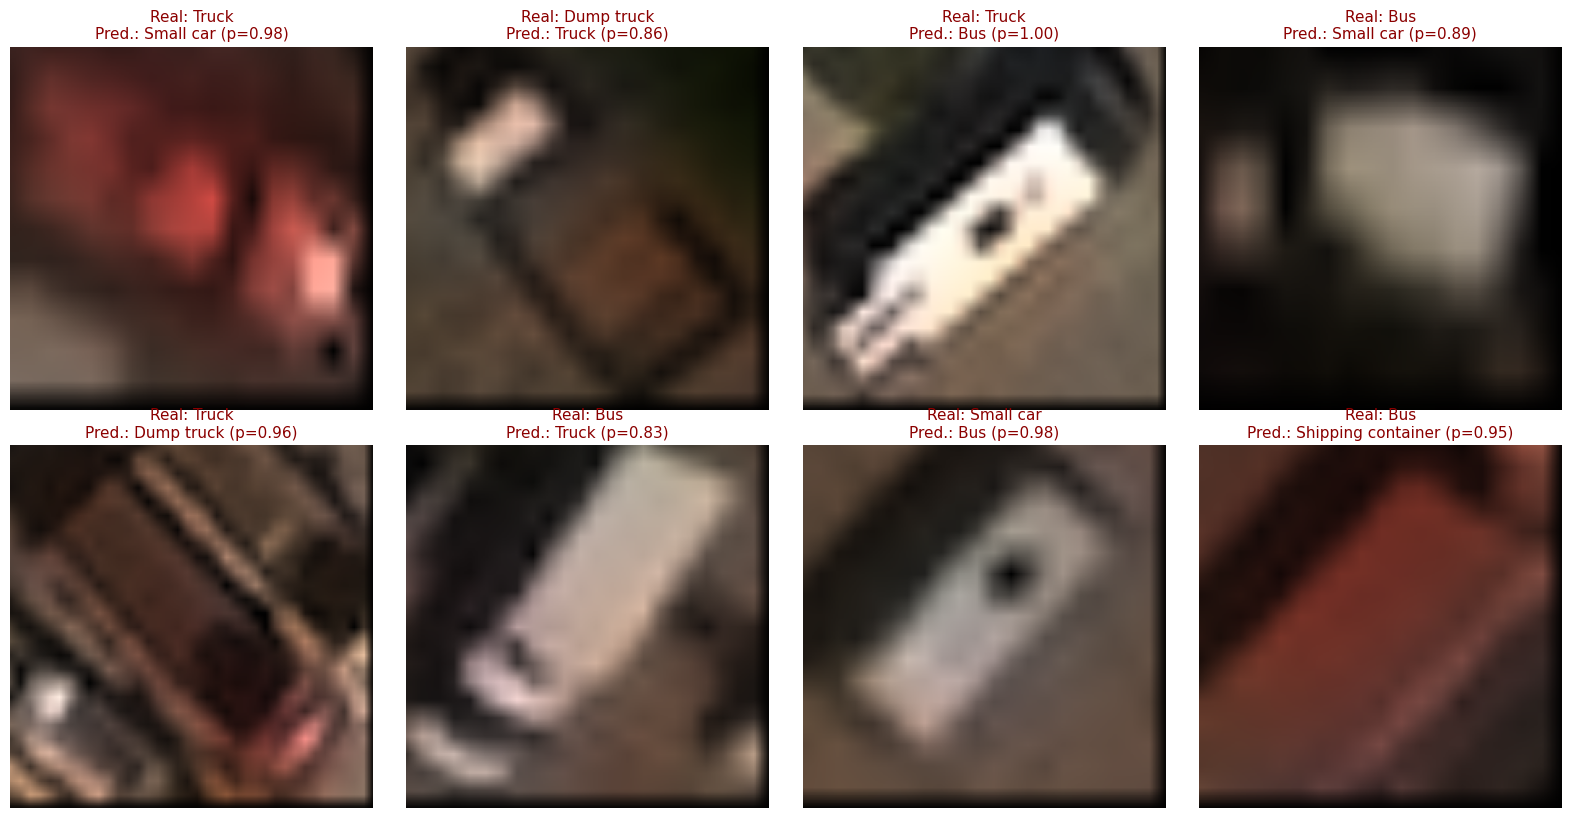

Archivos generados:
- /kaggle/working/tl_17_aciertos_cualitativos.png


/kaggle/working/tl_17_aciertos_cualitativos.png

- /kaggle/working/tl_17_errores_cualitativos.png


/kaggle/working/tl_17_errores_cualitativos.png

- /kaggle/working/tl_17_ejemplos_cualitativos.csv


/kaggle/working/tl_17_ejemplos_cualitativos.csv

/kaggle/working/17_resnet101_stage2_recovered.weights.h5

/kaggle/working/17_resnet101_stage3_recovered.weights.h5

In [7]:
def plot_examples(indices_to_plot, output_path, ncols, title_color):
    nrows = int(np.ceil(len(indices_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.1 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, indices_to_plot):
        true_name = category_names[int(y_true_idx[idx])]
        pred_name = category_names[int(y_pred_idx[idx])]
        ax.imshow(X_valid[idx])
        ax.set_title(
            f'Real: {true_name}\nPred.: {pred_name} (p={confidences[idx]:.2f})',
            color=title_color, fontsize=11,
        )
        ax.axis('off')

    for ax in axes[len(indices_to_plot):]:
        ax.axis('off')

    plt.tight_layout()
    fig.savefig(output_path, dpi=220, bbox_inches='tight', facecolor='white')
    plt.show()

correct_path = WORKDIR / 'tl_17_aciertos_cualitativos.png'
errors_path = WORKDIR / 'tl_17_errores_cualitativos.png'
csv_path = WORKDIR / 'tl_17_ejemplos_cualitativos.csv'

plot_examples(selected_correct[:6], correct_path, ncols=3, title_color='darkgreen')
plot_examples(selected_errors[:8], errors_path, ncols=4, title_color='darkred')

with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['tipo', 'indice_validacion', 'filename', 'clase_real', 'prediccion', 'confianza', 'frecuencia_par'])
    for kind, indices_group in [('acierto', selected_correct[:6]), ('error', selected_errors[:8])]:
        for idx in indices_group:
            writer.writerow([
                kind,
                idx,
                filenames[val_idx[idx]],
                category_names[int(y_true_idx[idx])],
                category_names[int(y_pred_idx[idx])],
                float(confidences[idx]),
                selected_error_counts.get(idx, ''),
            ])

print('Archivos generados:')
for path in [correct_path, errors_path, csv_path]:
    print('-', path)
    display(FileLink(str(path)))

for path in [stage2_output, stage3_output]:
    if path.exists():
        display(FileLink(str(path)))